# NEOFC - Influence of covariates on NET NEOFC estimates

In [4]:
from pathlib import Path 
import pandas as pd 
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt 
from PIL import Image
import seaborn as sn
import seaborn.objects as so

from utils import  load_neofc_stats

# working directory
wd = Path.cwd() 
print(wd)

# general vars
from utils import REF_MATH_NAMES, REF_NAMES_RSN

/Users/llotter/projects/mapfc


## Data

### Mapconn stats: MRI

In [5]:
parc = "Schaefer200"

neofc_ya_mri_cov_groupstats, neofc_ya_mri_cov_indivstats = load_neofc_stats(
    "hcp_ya_mri", parc, dset="cov", stats="auc")
#neofc_ya_mri_cov_groupstats

Loading group stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ya_mri/parc-..._dset-cov_stat-..._group.csv.gz
Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ya_mri/parc-..._dset-cov_stat-..._individual.csv.gz


## Plots

### MRI AUCs

In [6]:
def plot_mri_overview(parc, measure, connections, axes, maps, stat="auc", plot_brains=True, z_vs_null=True):
    
    # null variables
    null_vars = ["null_1%", "null_10%", "null_25%", "null_50%", "null_75%", "null_90%", "null_99%",
                 "null_mean", "null_std"]
    
    # DATA
    dfs = {}
    for metric in ["original", "inverted"]:
        
        # actual data
        var = "val" + ("_rz" if z_vs_null else "")
        df_data = (
            neofc_ya_mri_cov_indivstats
            .loc[(parc, measure, connections, 1, metric, stat, var, slice(None)), maps]
            .reset_index(drop=True)
            .describe([0.1,0.9])
        )
        
        # null data
        df_null = (
            neofc_ya_mri_cov_groupstats
            .loc[(parc, measure, connections, 1, "original", stat, null_vars), maps]
            .reset_index(drop=True)
            .assign(variable=null_vars).set_index("variable")
        )
        if z_vs_null:
            df_null = (df_null - df_null.loc["null_mean"].values) / df_null.loc["null_std"].values
        df_null = df_null.drop(index=["null_mean", "null_std"])
        
        # p
        df_p = (
            neofc_ya_mri_cov_groupstats
            .loc[(parc, measure, connections, 1, metric, stat, ["p", "pmeff"]), maps]
            .reset_index(drop=True)
            .assign(variable=["p", "pmeff"]).set_index("variable")
        )
            
        dfs[metric] = pd.concat([df_data, df_null, df_p], axis=0)
        # print(metric)
        #display(dfs[metric])
        
    # PLOT   
    def plot_bars(metric, ax, x_range, color_range, cmap, title=None, plot_wcv=False):
        df = dfs[metric]
        if title is None:
            title = f"$AUC_{{{metric.title()}}}$"
        ax_main = ax
        
        # bars
        (
            so.Plot(data=df.T)
            .add(so.Bar(edgecolor="k", edgewidth=1.5), x="mean", y=maps, color="mean", legend=False)
            .add(so.Range(color="k"), y=maps, xmin="10%", xmax="90%")
            .scale(color=so.Continuous(cmap, norm=color_range))
            .limit(x=x_range)
            .on(ax_main)
            .plot()
        )
        
        # nulls
        ax_main.plot(df.loc["null_50%", maps], maps, lw=1.5, color="0.3", zorder=-1000)
        for p1, p2, c in [("null_1%", "null_99%", "0.9"), 
                        ("null_10%", "null_90%", "0.8"), 
                        ("null_25%", "null_75%", "0.7")]:
            ax_main.fill_betweenx(
                maps, 
                df.loc[p1, maps].values, 
                df.loc[p2, maps].values, 
                color=c, 
                zorder=-1001,
                alpha=1,
                label=f"{p2.replace('null_', '')} PI of null means"
            )
            
        # significance
        for l in ax_main.get_yticklabels():
            m = l.get_text()
            p = df.loc["p", m]
            x_offset = np.diff(ax_main.get_xlim()) * 0.02
            x = max(df.loc["90%", m], df.loc["mean", m], 0) + x_offset
            y = l.get_position()[1]
            ax_main.annotate(f"{p:.3f}", (x, y), ha="left", va="center", fontsize=10, color="k")
                
        # layout
        ax.set_title(title, pad=10)
        ax_main.set_ylim(len(maps), -1)
        ax_main.set_xlim(x_range)
        ax_main.set_xlabel("Z(AUC)" if z_vs_null else "AUC")
        if not ax.get_subplotspec().is_first_col():
            ax_main.set_yticklabels([])            

        return ax_main.get_legend_handles_labels()
            
    
    # plot original
    xmin = min([ dfs["original"].loc["90%"].min(), dfs["inverted"].loc["90%"].min() ]) * 2
    xmax = max([ dfs["original"].loc["90%"].max(), dfs["inverted"].loc["90%"].max() ]) * 2.2
    vmax = max([ dfs["original"].loc["mean"].abs().max(), dfs["inverted"].loc["mean"].abs().max() ])
    vmin = -vmax
    handles, labels = plot_bars("original", axes[0], (xmin, xmax), (vmin, vmax), "vlag")
    
    # plot inverted
    plot_bars("inverted", axes[1], (xmin, xmax), (vmin, vmax), "vlag_r")

    # legend
    bar_handle = (plt.Rectangle((0, 0), 1, 1, color=sn.color_palette("vlag")[4], lw=1.5, ec="k", alpha=0.8),
                  plt.Line2D([0.5, 0], [2, 0], color="k", marker="none"))
    p_handle = plt.Line2D([0], [0], color="k", marker="$0.001$", markersize=22, markeredgewidth=0, linestyle="None") 
    handles = [bar_handle] + handles + [p_handle]
    labels = ["Mean Z(AUC) (90% PI)"] + labels + ["uncorrected p value"]
    axes[-1].legend(handles, labels, loc="center left", bbox_to_anchor=(1.1, 0.5),
                    handler_map={bar_handle: mpl.legend_handler.HandlerTuple(ndivide=None, pad=-0.5)})
    
    # BRAINS & LABELS
    if plot_brains:
        # new axis for brains and labels
        ax_brains = axes[0].inset_axes((-0.9, 0, 1.1, 1))
        ax_brains.set_ylim(axes[0].get_ylim())
        ax_brains.set_axis_off()
        
        # iterate labels
        for l in axes[0].get_yticklabels():
            m = l.get_text()
            y = l.get_position()[1]
            
            # plot brain
            ax_img = ax_brains.inset_axes((0, y-0.5, 1, 1), transform=ax_brains.transData)
            ax_img.imshow(Image.open(wd / "plots" / "reference" / f"reference-{m.replace(' ', '').replace('-', '')}_parc-{parc}.png"))
            ax_img.set_axis_off()
            
            # plot label
            ax_img.annotate(REF_MATH_NAMES[m] if m in REF_MATH_NAMES else f"${m}$", 
                            xy=(-0.1, 0.5), xycoords="axes fraction", ha="right", va="center", 
                            fontsize=10, weight=l.get_weight(), color="k")
    
        # remove old labels
        axes[0].set_yticklabels([])
    else:
        axes[0].set_yticks(axes[0].get_yticks(), labels=[REF_MATH_NAMES[m] if m in REF_MATH_NAMES else f"${m}$" for m in maps])


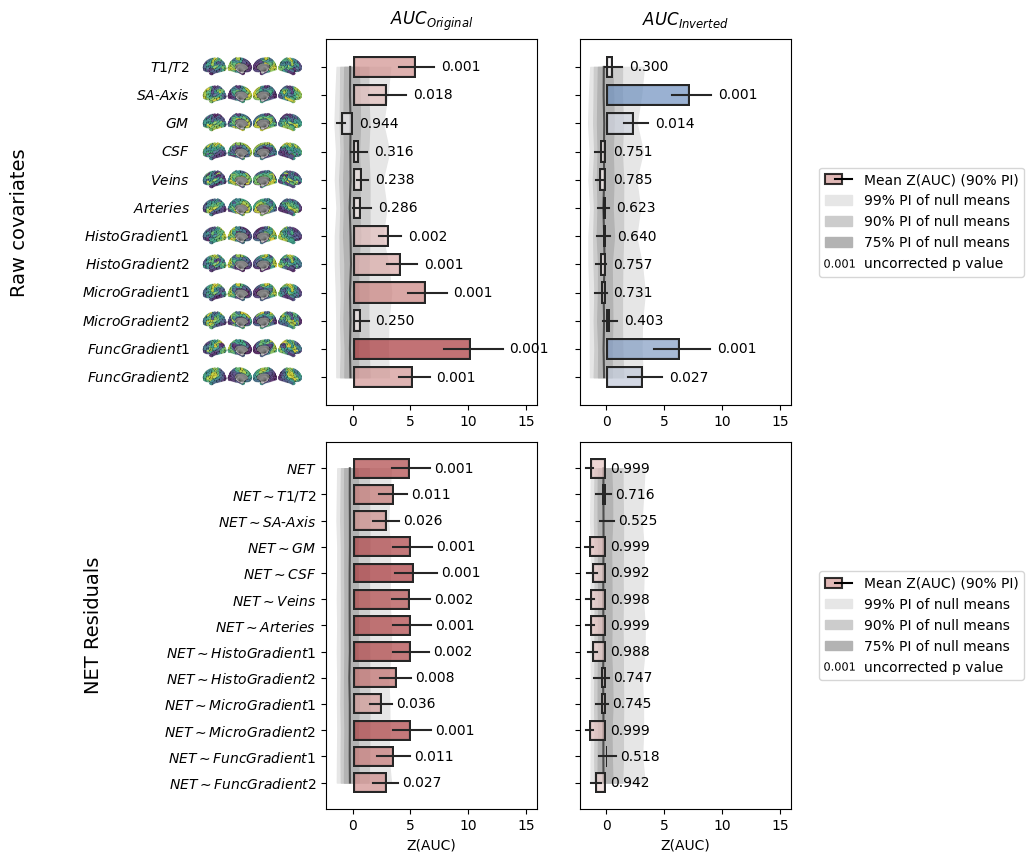

In [7]:
parc = "Schaefer200"
measure = "pearson"
stat = "auc"

fig, axes = plt.subplots(2, 2, figsize=(6, 10), sharey=False, sharex="col", gridspec_kw={"hspace": 0.1})
maps = ["t1t2", "saaxis", "gm", "csf", "veins", "arteries",
        "histogradient1", "histogradient2", "microgradient1", "microgradient2", "funcgradient1", "funcgradient2"]

plot_mri_overview(
    parc, measure, "all", axes[0,:], 
    stat=stat,
    maps=maps,
    plot_brains=True
)
plot_mri_overview(
    parc, measure, "all", axes[1,:], 
    stat=stat,
    maps=["NET"] + [f"NET-{m}" for m in maps],
    plot_brains=False
)
for ax in axes[0,:]:
    ax.set_xlabel("")
for ax in axes[1,:]:
    ax.set_title("")
axes[0,0].annotate("Raw covariates", xy=(-1.45, 0.5), xycoords="axes fraction", ha="center", va="center", fontsize=14, color="k", rotation=90)
axes[1,0].annotate("NET Residuals", xy=(-1.1, 0.5), xycoords="axes fraction", ha="center", va="center", fontsize=14, color="k", rotation=90)
fig.savefig(wd / "plots" / "covariates" / f"covoverview_parc-{parc}_measure-{measure}.pdf", bbox_inches="tight", dpi=400)
